In [1]:
# %%
import numpy as np
import torch
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

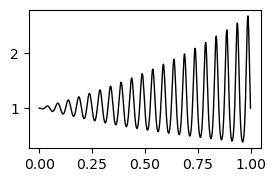

In [9]:
x = np.linspace(0, 1, 1000)
def func(x):
    return np.exp(-np.sin(40*np.pi*x) * x)
f = func(x)
plt.figure(figsize=(3, 1.8))
plt.plot(x, f, 'k-', linewidth=1)
plt.show()

data.shape = (250, 2000)
data.dtype = float32


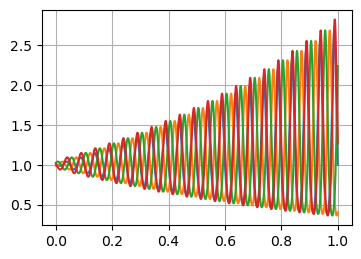

In [13]:
N = 250         # Number of data points
L = 2000         # Sequence length
a = np.linspace(0, 1, L)
b = np.linspace(0, 1, N).reshape((N, 1))
xx = np.linspace(0, 1, L)
x = a + b
data = func(x).astype(np.float32)
print(f"data.shape = {data.shape}")
print(f"data.dtype = {data.dtype}")

plt.figure(figsize=(4, 2.8))
for idx in range(4):
    plt.plot(xx, data[4 * idx])
plt.grid(True)

In [14]:
class Sequence(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(Sequence, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.lstm1 = nn.LSTMCell(input_size=input_size, hidden_size=hidden_size)
        self.lstm2 = nn.LSTMCell(input_size=hidden_size, hidden_size=hidden_size)
        self.linear = nn.Linear(in_features=hidden_size, out_features=output_size)

    def forward(self, input, future = 0):
        outputs = []
        h_t = torch.zeros(input.shape[0], self.hidden_size, dtype=torch.float32)
        c_t = torch.zeros(input.shape[0], self.hidden_size, dtype=torch.float32)
        h_t2 = torch.zeros(input.shape[0], self.hidden_size, dtype=torch.float32)
        c_t2 = torch.zeros(input.shape[0], self.hidden_size, dtype=torch.float32)

        seq_length = input.shape[1]
        for i in range(seq_length):
            input_t = input[:,i].reshape((-1, 1))
            h_t, c_t = self.lstm1(input_t, (h_t, c_t))
        # for input_t in input.split(1, dim=1):
            # h_t, c_t = self.lstm1(input_t, (h_t, c_t))
            h_t2, c_t2 = self.lstm2(h_t, (h_t2, c_t2))
            output = self.linear(h_t2)
            outputs.append(output)

        for i in range(future):# if we should predict the future
            h_t, c_t = self.lstm1(output, (h_t, c_t))
            h_t2, c_t2 = self.lstm2(h_t, (h_t2, c_t2))
            output = self.linear(h_t2)
            outputs.append(output)
            
        outputs = torch.cat(outputs, dim=1)
        return outputs

In [15]:
# set random seed to 0
np.random.seed(0)
torch.manual_seed(0)
# load data and make training set
input = torch.from_numpy(data[3:, :-1])
target = torch.from_numpy(data[3:, 1:])
test_input = torch.from_numpy(data[:3, :-1])
test_target = torch.from_numpy(data[:3, 1:])

print(f"input.shape = {input.shape}")
print(f"target.shape = {target.shape}")

input.shape = torch.Size([247, 1999])
target.shape = torch.Size([247, 1999])


In [16]:
# build the model
model = Sequence(input_size=1, hidden_size=50, output_size=1)
output = model(input)
print(f"input.shape = {input.shape}")
print(f"output.shape = {output.shape}")

input.shape = torch.Size([247, 1999])
output.shape = torch.Size([247, 1999])


In [17]:
criterion = nn.MSELoss()
# use LBFGS as optimizer since we can load the whole data to train
optimizer = optim.LBFGS(model.parameters(), lr=0.8)

In [18]:
#begin to train
EPOCHS = 15
for step in range(EPOCHS):
    print('STEP: ', step)
    def closure():
        optimizer.zero_grad()
        out = model(input)
        loss = criterion(out, target)
        print('loss:', loss.item())
        loss.backward()
        return loss
    optimizer.step(closure)
    # begin to predict, no need to track gradient here
    with torch.no_grad():
        future = 250
        pred = model(test_input, future=future)
        loss = criterion(pred[:, :-future], test_target)
        print('test loss:', loss.item())
        y = pred.detach().numpy()
    # draw the result
    plt.figure(figsize=(30,10))
    plt.title('Predict future values for time sequences\n(Dashlines are predicted values)', fontsize=30)
    plt.xlabel('x', fontsize=20)
    plt.ylabel('y', fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    def draw(yi, color):
        plt.plot(np.arange(input.size(1)), yi[:input.size(1)], color, linewidth = 2.0)
        plt.plot(np.arange(input.size(1), input.size(1) + future), yi[input.size(1):], color + ':', linewidth = 2.0)
    draw(y[0], 'r')
    draw(y[1], 'g')
    draw(y[2], 'b')
    plt.savefig(f'./figures/periodic-wave-prediction-step-{step+1}.png')
    plt.close()

STEP:  0
loss: 2.832521677017212
loss: 2.7139956951141357
loss: 0.9699834585189819
loss: 0.9287285804748535
loss: 0.7610836029052734
loss: 9.419809341430664
loss: 0.8481699228286743
loss: 0.530182957649231
loss: 0.2249341458082199
loss: 0.15674540400505066
loss: 0.10829932987689972
loss: 0.07610820978879929
loss: 0.0573149099946022
loss: 0.042769912630319595
loss: 0.03015865385532379
loss: 0.034387052059173584
loss: 0.013835666701197624
loss: 0.008128401823341846
loss: 0.005263049621134996
loss: 0.0020996220409870148
test loss: 0.0008496688678860664
STEP:  1
loss: 0.0018499164143577218
loss: 0.001802777056582272
loss: 0.0017257708823308349
loss: 0.0015293003525584936
loss: 0.0013838193845003843
loss: 0.0011467034928500652
loss: 0.0009786029113456607
loss: 0.0008525655139237642
loss: 0.0008024718263186514
loss: 0.0007683430449105799
loss: 0.0007037234609015286
loss: 0.0006746434373781085
loss: 0.0006152755813673139
loss: 0.000525966752320528
loss: 0.000489857280626893
loss: 0.0004723893

In [19]:
model = Sequence(input_size=1, hidden_size=51, output_size=1)
model.float()

Sequence(
  (lstm1): LSTMCell(1, 51)
  (lstm2): LSTMCell(51, 51)
  (linear): Linear(in_features=51, out_features=1, bias=True)
)

In [20]:
criterion = nn.MSELoss()
optimizer = optim.LBFGS(model.parameters(), lr=0.8)

In [21]:
input = torch.from_numpy(data[3:, :-1])
target = torch.from_numpy(data[3:, 1:])

input_test = torch.from_numpy(data[:3, :-1])
target_test = torch.from_numpy(data[:3, 1:])

print(f"input.shape = {input.shape}")
print(f"target.shape = {target.shape}")
print(f"input_test.shape = {input_test.shape}")
print(f"target_test.shape = {target_test.shape}")

input.shape = torch.Size([247, 1999])
target.shape = torch.Size([247, 1999])
input_test.shape = torch.Size([3, 1999])
target_test.shape = torch.Size([3, 1999])


In [22]:
input_split = input.split(1, dim=1)

In [23]:
print(f"length of input_split = {len(input_split)}")
print(f"input_split[0] = {input_split[0].shape}")

length of input_split = 1999
input_split[0] = torch.Size([247, 1])


In [24]:
output = model(input)
print(f"input.shape = {input.shape}")
print(f"output.shape = {output.shape}")

input.shape = torch.Size([247, 1999])
output.shape = torch.Size([247, 1999])


In [106]:
EPOCHS = 1
for epoch in range(EPOCHS):
    def closure():
        optimizer.zero_grad()
        out = model(input)

        loss = criterion(out, target)
        print(f"loss = {loss.item()}")
        loss.backward()
        return loss

    optimizer.step(closure)

loss = 2.480393959558569e-06
loss = 2.4519131329725496e-06
loss = 2.4423140985163627e-06
loss = 2.4194775960495463e-06
loss = 2.4079411105049076e-06
loss = 2.3948084617586574e-06
loss = 2.3854013306845445e-06
loss = 2.375907115492737e-06
loss = 2.3653797143197153e-06
loss = 2.357838184252614e-06
loss = 2.3550646801595576e-06
loss = 2.3534055344498483e-06
loss = 2.3520724425907247e-06
loss = 2.3505631361331325e-06
loss = 2.3499874259869102e-06


In [116]:
with torch.no_grad():
    future = 1000
    pred = model(input_test, future=future)
    print(f"pred.shape = {pred.shape}")

    loss = criterion(pred[:,:-future], target_test)
    
print(f"Test loss = {loss.item()}")
y = pred.detach().numpy()
print(f"y.shape = {y.shape}")

pred.shape = torch.Size([3, 1999])
Test loss = 1.185866949526826e-05
y.shape = (3, 1999)
